In [52]:
# =========================
# Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [53]:
# =========================
# Imports and Dataset Path
# =========================
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

image_data_root = '/content/dataset/khana'

print(f"Using dataset path: {image_data_root}")

Using dataset path: /content/dataset/khana


In [54]:
# =========================
# Basic Dataset Structure Check
# =========================
if not os.path.exists(image_data_root):
    print("Dataset path does not exist. Please check the path.")
else:
    all_categories = [
        d for d in os.listdir(image_data_root)
        if os.path.isdir(os.path.join(image_data_root, d))
    ]

    print(f"Total categories found: {len(all_categories)}")
    print("\nSample category names:")
    print(all_categories[:10])

Total categories found: 80

Sample category names:
['khakhra', 'margherita pizza', 'mysore pak', 'banana chips', 'phirni', 'thukpa', 'besan laddu', 'moong dal halwa', 'pongal', 'paniyaram']


In [55]:
# =========================
# Count Images in Each Category
# =========================
category_counts = {}
total_images = 0

for category in all_categories:
    category_path = os.path.join(image_data_root, category)

    # Count all files except hidden/system files
    image_files = [
        f for f in os.listdir(category_path)
        if not f.startswith('.') and os.path.isfile(os.path.join(category_path, f))
    ]

    count = len(image_files)
    category_counts[category] = count
    total_images += count

print("Image count per category:\n")
for category, count in sorted(category_counts.items()):
    print(f"{category}: {count}")

print(f"\nTotal images in dataset: {total_images}")

Image count per category:

aloo gobi: 1007
aloo methi: 125
aloo mutter: 350
aloo paratha: 3155
amritsari kulcha: 267
anda curry: 3248
balushahi: 179
banana chips: 170
besan laddu: 483
bhindi masala: 598
biryani: 6639
boondi laddu: 226
chaas: 999
chana masala: 2873
chapati: 2238
chicken pizza: 3014
chicken wings: 2545
chikki: 201
chivda: 277
chole bhature: 1181
dabeli: 928
dal khichdi: 1252
dhokla: 1211
falooda: 2483
fish curry: 1553
gajar ka halwa: 357
garlic bread: 5668
garlic naan: 5730
ghevar: 294
grilled sandwich: 5705
gujhia: 269
gulab jamun: 2962
hara bhara kabab: 1621
idiyappam: 371
idli: 5835
jalebi: 962
kaju katli: 705
khakhra: 256
kheer: 670
kulfi: 3033
margherita pizza: 2460
masala dosa: 5894
masala papad: 1069
medu vada: 541
misal pav: 543
modak: 226
moong dal halwa: 204
murukku: 228
mysore pak: 306
navratan korma: 369
neer dosa: 215
onion pakoda: 292
palak paneer: 3385
paneer masala: 7884
paneer pizza: 2491
pani puri: 784
paniyaram: 267
papdi chaat: 999
patrode: 218
pav bh

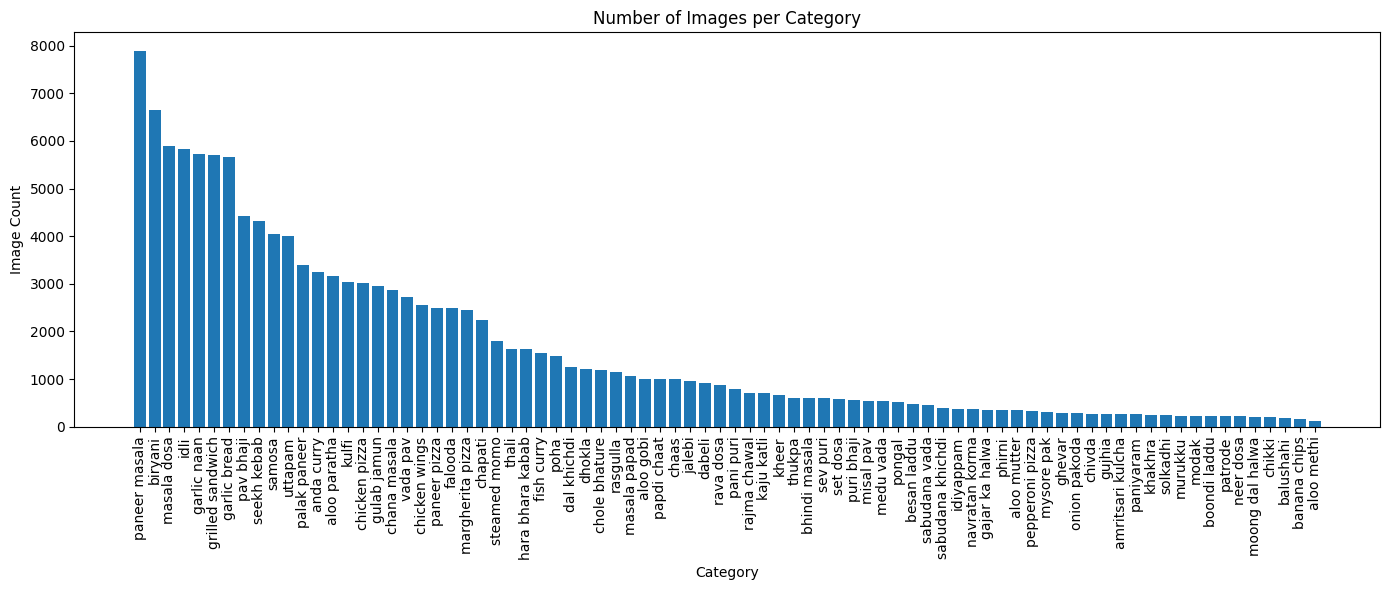


Class balance summary:
count      80.00000
mean     1647.73750
std      1825.68416
min       125.00000
25%       342.75000
50%       826.00000
75%      2504.50000
max      7884.00000
Name: Image_Count, dtype: float64


In [56]:
# =========================
# Class Distribution Plot
# =========================
count_df = pd.DataFrame({
    'Category': list(category_counts.keys()),
    'Image_Count': list(category_counts.values())
}).sort_values(by='Image_Count', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(count_df['Category'], count_df['Image_Count'])
plt.xticks(rotation=90)
plt.title("Number of Images per Category")
plt.xlabel("Category")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

print("\nClass balance summary:")
print(count_df['Image_Count'].describe())

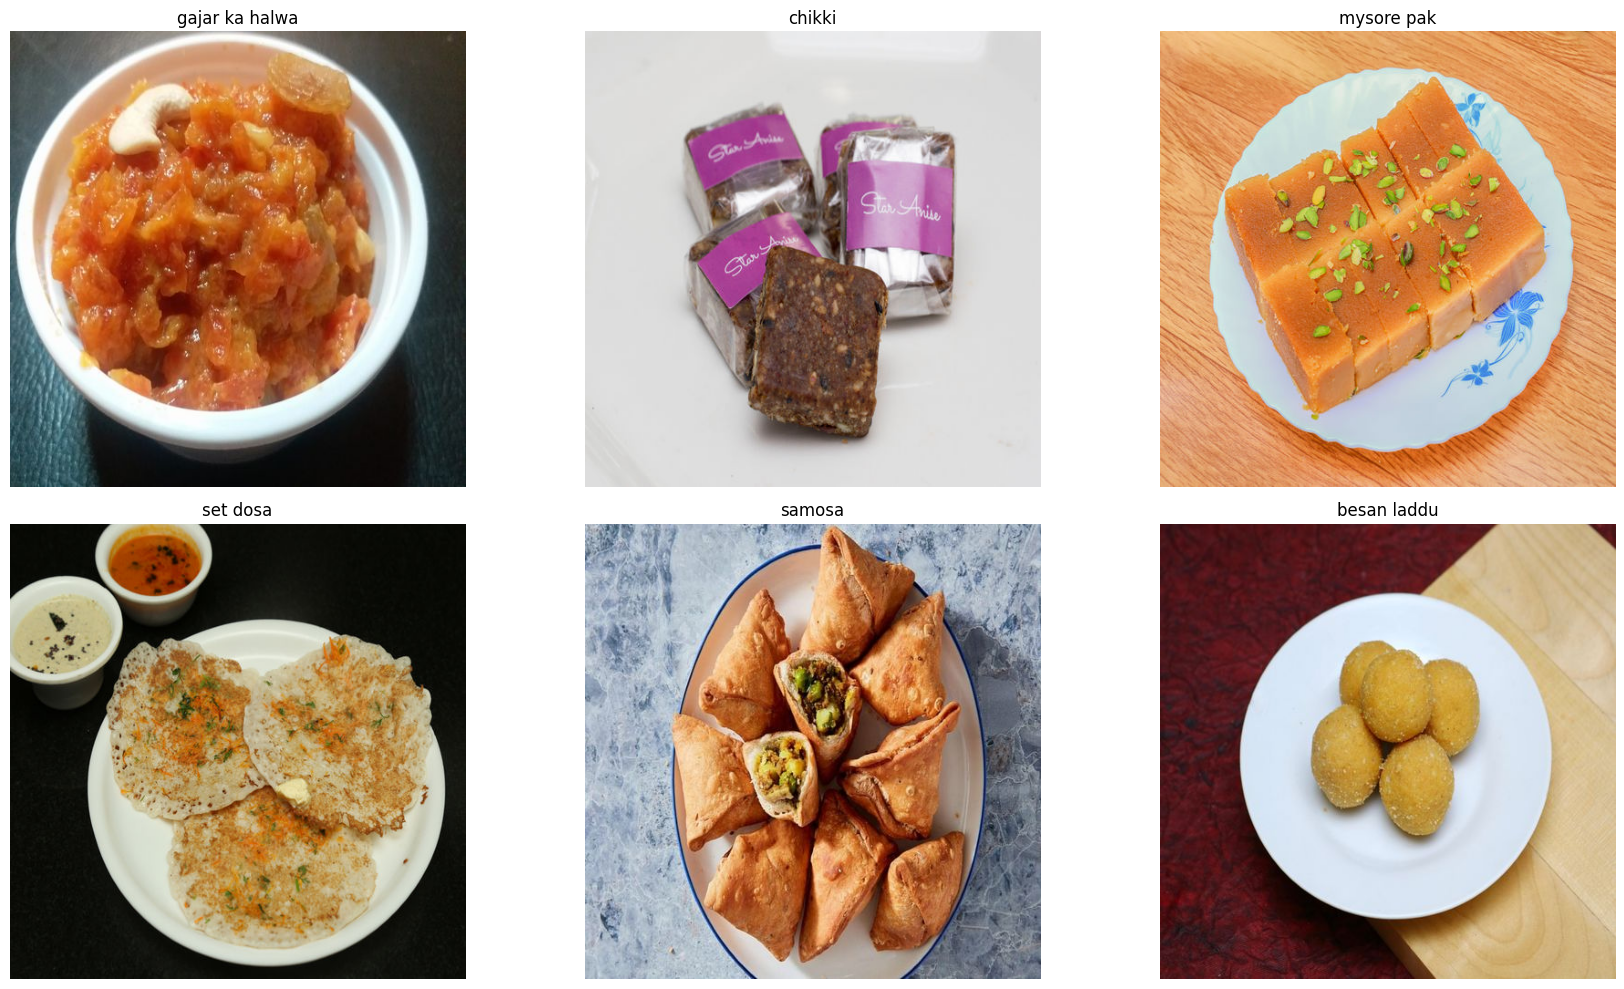

In [57]:
# =========================
# Display Random Sample Images
# =========================
num_categories_to_display = min(6, len(all_categories))
sample_categories = random.sample(all_categories, num_categories_to_display)

plt.figure(figsize=(18, 10))

plot_index = 1

for category in sample_categories:
    category_path = os.path.join(image_data_root, category)

    image_files = [
        f for f in os.listdir(category_path)
        if not f.startswith('.') and os.path.isfile(os.path.join(category_path, f))
    ]

    if len(image_files) == 0:
        continue

    random_image = random.choice(image_files)
    image_path = os.path.join(category_path, random_image)

    try:
        img = Image.open(image_path)

        plt.subplot(2, 3, plot_index)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')

        plot_index += 1

    except Exception as e:
        print(f"Could not open image: {image_path} | Error: {e}")

plt.tight_layout()
plt.show()

In [58]:
# =========================
# Image Size Analysis
# =========================
image_widths = []
image_heights = []
image_modes = []
aspect_ratios = []
corrupted_images = []

for category in all_categories:
    category_path = os.path.join(image_data_root, category)

    image_files = [
        f for f in os.listdir(category_path)
        if not f.startswith('.') and os.path.isfile(os.path.join(category_path, f))
    ]

    for image_file in image_files:
        image_path = os.path.join(category_path, image_file)

        try:
            with Image.open(image_path) as img:
                width, height = img.size
                mode = img.mode

                image_widths.append(width)
                image_heights.append(height)
                image_modes.append(mode)

                if height != 0:
                    aspect_ratios.append(width / height)

        except Exception:
            corrupted_images.append(image_path)

print(f"Total readable images: {len(image_widths)}")
print(f"Total corrupted/unreadable images: {len(corrupted_images)}")

Total readable images: 131819
Total corrupted/unreadable images: 0


In [59]:
# =========================
# Width and Height Summary
# =========================
if len(image_widths) > 0:
    print("Width Summary")
    print(f"Min: {min(image_widths)}")
    print(f"Max: {max(image_widths)}")
    print(f"Mean: {np.mean(image_widths):.2f}")
    print(f"Median: {np.median(image_widths):.2f}")

    print("\nHeight Summary")
    print(f"Min: {min(image_heights)}")
    print(f"Max: {max(image_heights)}")
    print(f"Mean: {np.mean(image_heights):.2f}")
    print(f"Median: {np.median(image_heights):.2f}")

Width Summary
Min: 500
Max: 4000
Mean: 500.03
Median: 500.00

Height Summary
Min: 500
Max: 3000
Mean: 500.02
Median: 500.00


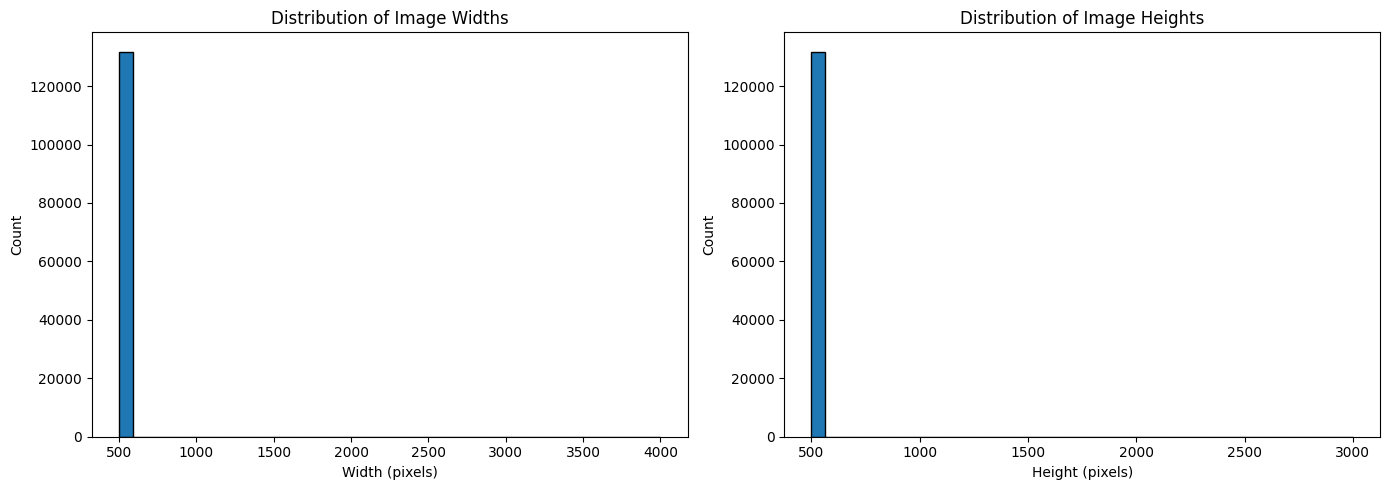

In [60]:
# =========================
# Plot Width and Height Distributions
# =========================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(image_widths, bins=40, edgecolor='black')
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(image_heights, bins=40, edgecolor='black')
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [61]:
# =========================
# Check Most Common Image Dimensions
# =========================
dimension_pairs = list(zip(image_widths, image_heights))
dimension_counts = Counter(dimension_pairs)

print("Top 10 most common image sizes:\n")
for dim, count in dimension_counts.most_common(10):
    print(f"{dim}: {count} images")

if len(dimension_counts) == 1:
    print("\nAll images have the same dimensions.")
else:
    print(f"\nImages have varying dimensions. Unique size pairs found: {len(dimension_counts)}")

Top 10 most common image sizes:

(500, 500): 131818 images
(4000, 3000): 1 images

Images have varying dimensions. Unique size pairs found: 2


Image mode distribution:

RGB: 131554
P: 265


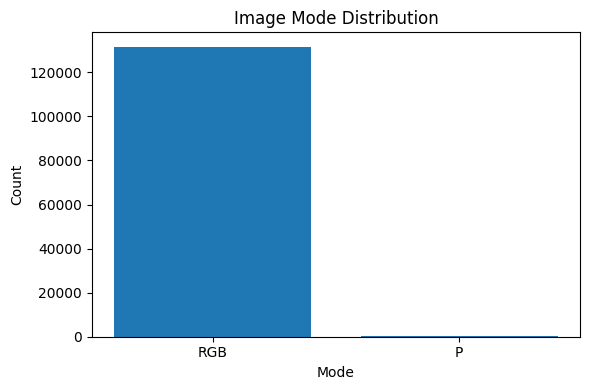

In [62]:
# =========================
# Image Mode Analysis (RGB / L / RGBA etc.)
# =========================
mode_counts = Counter(image_modes)

print("Image mode distribution:\n")
for mode, count in mode_counts.items():
    print(f"{mode}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(mode_counts.keys(), mode_counts.values())
plt.title("Image Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Aspect Ratio Summary
Min: 1.00
Max: 1.33
Mean: 1.00
Median: 1.00


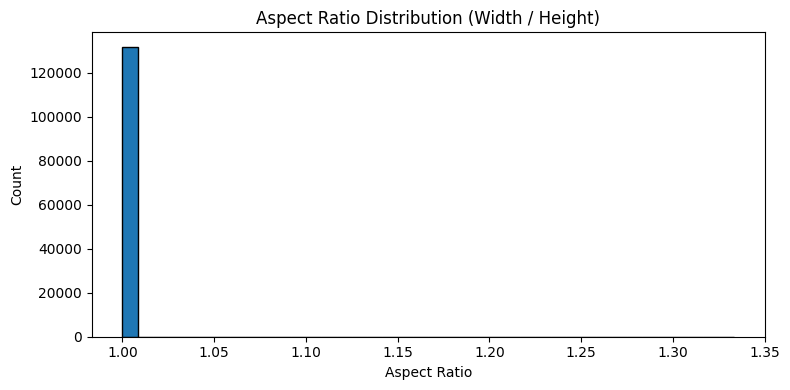

In [63]:
# =========================
# Aspect Ratio Analysis
# =========================
if len(aspect_ratios) > 0:
    print("Aspect Ratio Summary")
    print(f"Min: {min(aspect_ratios):.2f}")
    print(f"Max: {max(aspect_ratios):.2f}")
    print(f"Mean: {np.mean(aspect_ratios):.2f}")
    print(f"Median: {np.median(aspect_ratios):.2f}")

    plt.figure(figsize=(8, 4))
    plt.hist(aspect_ratios, bins=40, edgecolor='black')
    plt.title("Aspect Ratio Distribution (Width / Height)")
    plt.xlabel("Aspect Ratio")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()